In [14]:
# Imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from cd_dynamax import ContDiscreteNonlinearGaussianSSM, make_key_sequence
from cd_dynamax.src.utils.demo_utils import sample_t_emissions


Define the Lorenz 63 Drift Function


In [15]:
def drift_l63(x, sigma=10.0, rho=28.0, beta=8.0/3.0):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

In [ ]:
# System dimensions
state_dim = 3 # Lorenz '63 has 3 state dimensions
emission_dim = 1 # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 10.0
initial_state_sd_true = 30.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
cdnlgssm = ContDiscreteNonlinearGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)

# Build the true parameters
true_params = cdnlgssm.build_params(
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    drift=lambda x: drift_l63(x, sigma=10.0, rho=28.0, beta=8.0/3.0), # Lorenz '63 drift at true parameters
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)


Simulate data using true parameters

[make_t_emissions] Generated 100 points from 0.0 to 10.0 with avg step ~0.1000
[make_t_emissions] Smallest time step = 0.002118
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


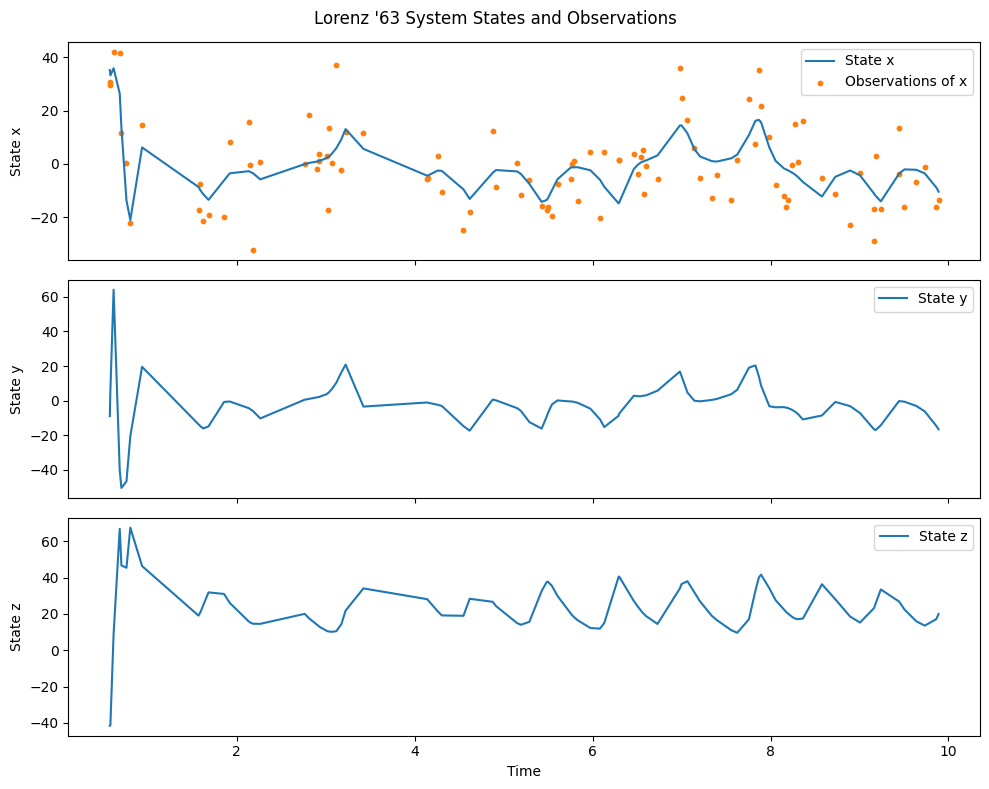

In [ ]:
keys = make_key_sequence(0)
t_emissions = sample_t_emissions(start=0.0, stop=10.0, dt=0.1, regular=False, key=next(keys))

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ['x', 'y', 'z']
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f'State {state_labels[i]}', color='C0')
    if i < emission_dim:
        axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C1', s=10)
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

Now perform filtering over the observed emissions using EnKF. This produces filtered state estimates at the observation times, but also, crucially, computes an estimate of the log likelihood of the observed data under the model.

In [ ]:
def filter_and_compute_loglik(params=true_params):
    # Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
    filtered_true = cdnlgssm.filter(
        params=true_params,
        emissions=emissions,
        t_emissions=t_emissions,
        key=next(keys),
        N_particles=100,
    )

    print("Negative-Log-likelihood (true params):", float(-filtered_true.marginal_loglik))

    # Plot a subfigure with state_dim rows showing true state, filtered mean and (optionally via shaded region) filtered stddev.
    # Also plot the observations in the first emission_dim rows.
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
    for i in range(state_dim):
        axs[i].plot(t_emissions, states[:, i], label=f'True State {state_labels[i]}', color='C0')
        axs[i].plot(t_emissions, filtered_true.filtered_means[:, i], label=f'Filtered Mean {state_labels[i]}', color='C1')
        axs[i].fill_between(
            t_emissions.squeeze(),
            filtered_true.filtered_means[:, i] - 2 * jnp.sqrt(filtered_true.filtered_covariances[:, i, i]),
            filtered_true.filtered_means[:, i] + 2 * jnp.sqrt(filtered_true.filtered_covariances[:, i, i]),
            color='C1',
            alpha=0.3,
            label=f'Filtered ±2 Stddev {state_labels[i]}'
        )
        if i < emission_dim:
            axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C2', s=10)
        axs[i].legend(loc='upper right')
        axs[i].set_ylabel(f'State {state_labels[i]}')

    return filtered_true.marginal_loglik
        

Negative-Log-likelihood (true params): 400.5703845748862


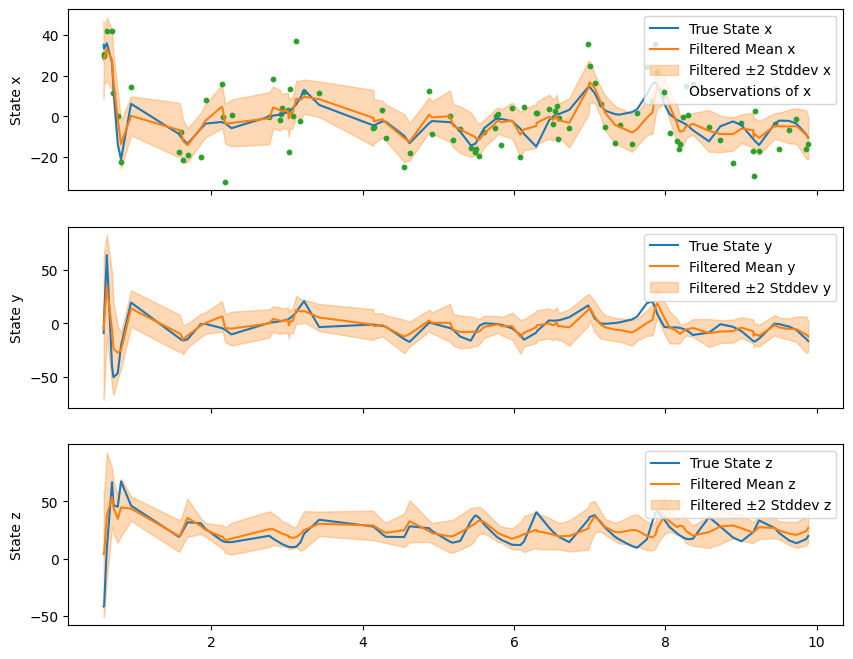

In [19]:
loglik_at_truth = filter_and_compute_loglik()

Negative-Log-likelihood (true params): 401.49727715146577


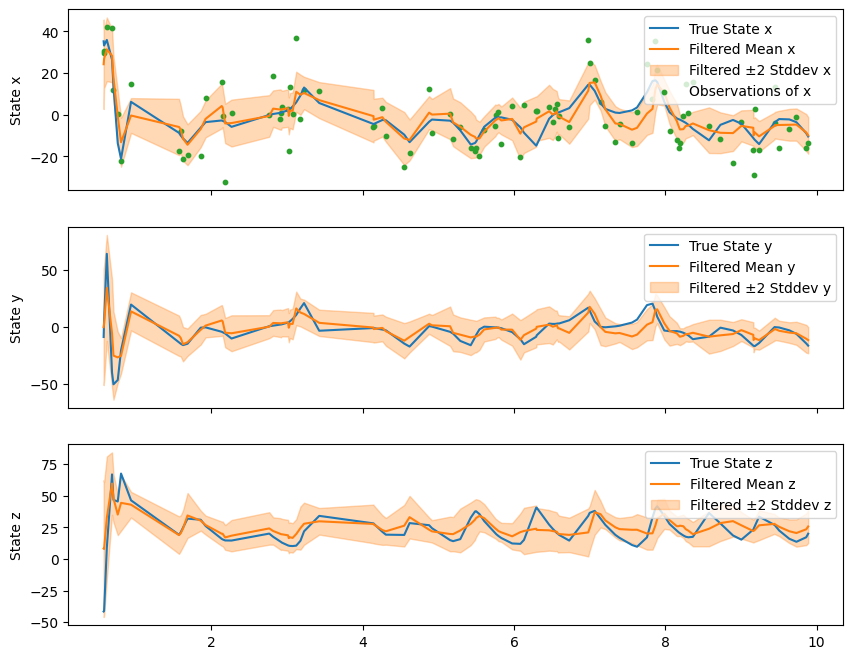

In [20]:
bad_params = cdnlgssm.build_params(
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    drift=lambda x: drift_l63(x, sigma=25.0, rho=15.0, beta=10.0), # Lorenz '63 drift at bad parameters
    diffusion_coeff=2.0 * diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(2.0 * emission_sd_true**2) * jnp.eye(emission_dim),
)
log_lik_at_bad = filter_and_compute_loglik(params=bad_params)

In [26]:
# Difference between log-likelihoods
print("Difference in log-likelihoods (True - Bad):", float(loglik_at_truth - log_lik_at_bad))
print("  >0 means True is better model than Bad")

Difference in log-likelihoods (True - Bad): 0.9268925765795757
  >0 means True is better model than Bad
